### Decoding from a CEBRA embedding

In [15]:
import sys
import numpy as np
import matplotlib.pyplot as plt
import cebra
import cebra.datasets
from cebra import CEBRA

Load the data

In [ ]:
hippocampus_pos = cebra.datasets.init('rat-hippocampus-single-achilles')
'''
includes:
hippocampus_pos.neural: high-dimensional neural activity (time x neurons)
hippocampus_pos.continuous_index: 2D labels: [x_position, direction]
'''

Train the models

In [17]:
max_iterations = 500 # quick CPU run-time demo
output_dimension = 32 

In [ ]:
def split_data(data, test_ratio):

    split_idx = int(len(data)* (1-test_ratio))
    neural_train = data.neural[:split_idx]
    neural_test = data.neural[split_idx:]
    label_train = data.continuous_index[:split_idx]
    label_test = data.continuous_index[split_idx:]

    return neural_train.numpy(), neural_test.numpy(), label_train.numpy(), label_test.numpy()

# 80% of the data for training and 20% for testing
neural_train, neural_test, label_train, label_test = split_data(hippocampus_pos, 0.2)

Train CEBRA-Behavior with position, direction, and/or both variables

In [ ]:
cebra_posdir_model = CEBRA(model_architecture='offset10-model',
                        batch_size=512,
                        learning_rate=3e-4,
                        temperature=1,
                        output_dimension=output_dimension,
                        max_iterations=max_iterations,
                        distance='cosine',
                        conditional='time_delta', # positive samples sampled based on time offsets
                        device='cuda_if_available',
                        verbose=True,
                        time_offsets=10)

cebra_pos_model = CEBRA(model_architecture='offset10-model',
                        batch_size=512,
                        learning_rate=3e-4,
                        temperature=1,
                        output_dimension=output_dimension,
                        max_iterations=max_iterations,
                        distance='cosine',
                        conditional='time_delta',
                        device='cuda_if_available',
                        verbose=True,
                        time_offsets=10)

cebra_dir_model = CEBRA(model_architecture='offset10-model',
                        batch_size=512,
                        learning_rate=3e-4,
                        temperature=1,
                        output_dimension=output_dimension,
                        max_iterations=max_iterations,
                        distance='cosine',
                        device='cuda_if_available',
                        verbose=True)

In [20]:
# Train CEBRA-Behavior models with both position and direction variables
cebra_posdir_model.fit(neural_train, label_train)
cebra_posdir_model.save("cebra_posdir_model.pt")

# Train CEBRA-Behavior models with position or direction variable
cebra_pos_model.fit(neural_train, label_train[:,0])
cebra_pos_model.save("cebra_pos_model.pt")

cebra_dir_model.fit(neural_train, label_train[:,1])
cebra_dir_model.save("cebra_dir_model.pt")

pos: -0.8298 neg:  6.4196 total:  5.5898 temperature:  1.0000: 100%|██████████| 500/500 [00:24<00:00, 20.72it/s]
pos: -0.8189 neg:  6.4897 total:  5.6707 temperature:  1.0000: 100%|██████████| 500/500 [00:23<00:00, 20.93it/s]
pos: -0.7802 neg:  6.4837 total:  5.7035 temperature:  1.0000: 100%|██████████| 500/500 [00:22<00:00, 22.49it/s]


Train shuffled CEBRA-Behavior with position, direction variables and both

In [21]:
cebra_posdir_shuffled_model = CEBRA(model_architecture='offset10-model',
                        batch_size=512,
                        learning_rate=3e-4,
                        temperature=1,
                        output_dimension=output_dimension,
                        max_iterations=max_iterations,
                        distance='cosine',
                        conditional='time_delta',
                        device='cuda_if_available',
                        verbose=True,
                        time_offsets=10)

cebra_pos_shuffled_model = CEBRA(model_architecture='offset10-model',
                        batch_size=512,
                        learning_rate=3e-4,
                        temperature=1,
                        output_dimension=output_dimension,
                        max_iterations=max_iterations,
                        distance='cosine',
                        conditional='time_delta',
                        device='cuda_if_available',
                        verbose=True,
                        time_offsets=10)

cebra_dir_shuffled_model = CEBRA(model_architecture='offset10-model',
                        batch_size=512,
                        learning_rate=3e-4,
                        temperature=1,
                        output_dimension=output_dimension,
                        max_iterations=max_iterations,
                        distance='cosine',
                        device='cuda_if_available',
                        verbose=True)

In [ ]:
# Shuffle the behavioral labels (breaking the link with the neural data), then retrain

# Generate shuffled behavior labels for train set
shuffled_posdir = np.random.permutation(label_train)
shuffled_pos = np.random.permutation(label_train[:,0])
shuffled_dir = np.random.permutation(label_train[:,1])


# Train the models with shuffled behavior variables
cebra_posdir_shuffled_model.fit(neural_train, shuffled_posdir)
cebra_posdir_shuffled_model.save("cebra_posdir_shuffled_model.pt")

cebra_pos_shuffled_model.fit(neural_train, shuffled_pos)
cebra_pos_shuffled_model.save("cebra_pos_shuffled_model.pt")

cebra_dir_shuffled_model.fit(neural_train, shuffled_dir)
cebra_dir_shuffled_model.save("cebra_dir_shuffled_model.pt")

pos: -0.4244 neg:  6.5534 total:  6.1290 temperature:  1.0000: 100%|██████████| 500/500 [00:23<00:00, 21.44it/s]
pos: -0.3831 neg:  6.5194 total:  6.1363 temperature:  1.0000: 100%|██████████| 500/500 [00:21<00:00, 22.78it/s]
pos: -0.5048 neg:  6.5053 total:  6.0004 temperature:  1.0000: 100%|██████████| 500/500 [00:22<00:00, 22.03it/s]


Load the models and get the corresponding embeddings

In [ ]:
# We get train set embedding and test set embedding (not shuffled models)
# embeddings = compressed, learned representations of the neural activity

cebra_posdir_model = cebra.CEBRA.load("cebra_posdir_model.pt", weights_only=False)
cebra_posdir_train = cebra_posdir_model.transform(neural_train)
cebra_posdir_test = cebra_posdir_model.transform(neural_test)

cebra_pos_model = cebra.CEBRA.load("cebra_pos_model.pt", weights_only=False)
cebra_pos_train = cebra_pos_model.transform(neural_train)
cebra_pos_test = cebra_pos_model.transform(neural_test)

cebra_dir_model = cebra.CEBRA.load("cebra_dir_model.pt", weights_only=False)
cebra_dir_train = cebra_dir_model.transform(neural_train)
cebra_dir_test = cebra_dir_model.transform(neural_test)

In [24]:
# We get train set embedding and test set embedding (shuffled models)

cebra_posdir_shuffled_model = cebra.CEBRA.load("cebra_posdir_shuffled_model.pt", weights_only=False)
cebra_posdir_shuffled_train = cebra_posdir_shuffled_model.transform(neural_train)
cebra_posdir_shuffled_test = cebra_posdir_shuffled_model.transform(neural_test)

cebra_pos_shuffled_model = cebra.CEBRA.load("cebra_pos_shuffled_model.pt", weights_only=False)
cebra_pos_shuffled_train = cebra_pos_shuffled_model.transform(neural_train)
cebra_pos_shuffled_test = cebra_pos_shuffled_model.transform(neural_test)

cebra_dir_shuffled_model = cebra.CEBRA.load("cebra_dir_shuffled_model.pt", weights_only=False)
cebra_dir_shuffled_train = cebra_dir_shuffled_model.transform(neural_train)
cebra_dir_shuffled_test = cebra_dir_shuffled_model.transform(neural_test)

In [25]:
cebra_pos_all = cebra_pos_model.transform(hippocampus_pos.neural)
cebra_dir_all = cebra_dir_model.transform(hippocampus_pos.neural)
cebra_posdir_all = cebra_posdir_model.transform(hippocampus_pos.neural)

cebra_pos_shuffled_all = cebra_pos_shuffled_model.transform(hippocampus_pos.neural)
cebra_dir_shuffled_all = cebra_dir_shuffled_model.transform(hippocampus_pos.neural)
cebra_posdir_shuffled_all = cebra_posdir_shuffled_model.transform(hippocampus_pos.neural)

Decode the labels from the embeddings

In [ ]:
import sklearn.metrics

# kNN decoder (fixed number of neighbors 36)
def decoding_pos_dir(embedding_train, embedding_test, label_train, label_test):
   # train two decoders (one for position, one for direction)
   # each decoder stores the (embedding_train, label_train) pairs so it can later find nearest neighbors for any test point
   pos_decoder = cebra.KNNDecoder(n_neighbors=36, metric="cosine")
   dir_decoder = cebra.KNNDecoder(n_neighbors=36, metric="cosine")

   pos_decoder.fit(embedding_train, label_train[:,0]) # learn position from embedding
   dir_decoder.fit(embedding_train, label_train[:,1]) # learn direction from embedding

   pos_pred = pos_decoder.predict(embedding_test)
   dir_pred = dir_decoder.predict(embedding_test)

   prediction = np.stack([pos_pred, dir_pred],axis = 1)

   test_score = sklearn.metrics.r2_score(label_test[:,:2], prediction) # R² over both outputs
   pos_test_err = np.median(abs(prediction[:,0] - label_test[:, 0])) # median error in position 
   pos_test_score = sklearn.metrics.r2_score(label_test[:, 0], prediction[:,0]) # R² for position

   return test_score, pos_test_err, pos_test_score

Decode the position and direction from the trained hypothesis models

In [28]:
cebra_posdir_decode = decoding_pos_dir(cebra_posdir_train, cebra_posdir_test, label_train, label_test)
cebra_pos_decode = decoding_pos_dir(cebra_pos_train, cebra_pos_test, label_train, label_test)
cebra_dir_decode = decoding_pos_dir(cebra_dir_train, cebra_dir_test, label_train, label_test)

cebra_posdir_shuffled_decode = decoding_pos_dir(cebra_posdir_shuffled_train, cebra_posdir_shuffled_test, label_train, label_test)
cebra_pos_shuffled_decode = decoding_pos_dir(cebra_pos_shuffled_train, cebra_pos_shuffled_test, label_train, label_test)
cebra_dir_shuffled_decode = decoding_pos_dir(cebra_dir_shuffled_train, cebra_dir_shuffled_test, label_train, label_test)

Visualize the decoding results and loss - decoding performance

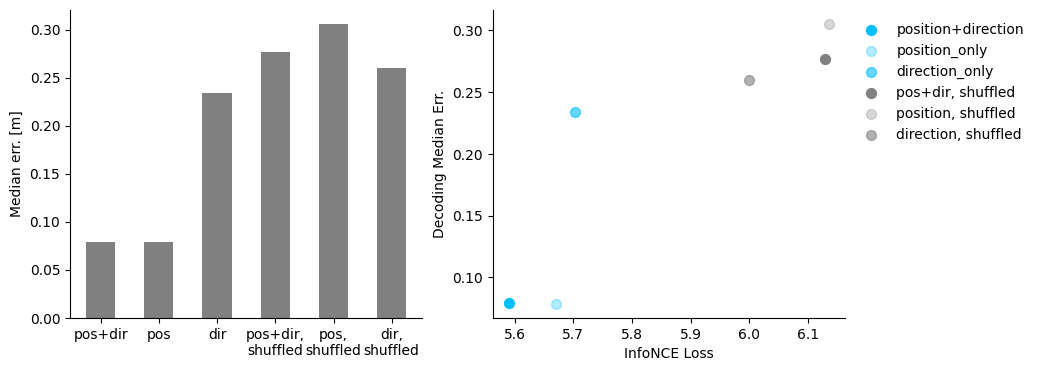

In [29]:
fig = plt.figure(figsize=(10,4))

ax1= plt.subplot(121)
ax1.bar(np.arange(6),
        [cebra_posdir_decode[1], cebra_pos_decode[1], cebra_dir_decode[1],
         cebra_posdir_shuffled_decode[1], cebra_pos_shuffled_decode[1], cebra_dir_shuffled_decode[1]],
         width = 0.5, color = 'gray')
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.set_xticks(np.arange(6))
ax1.set_xticklabels(['pos+dir', 'pos', 'dir', 'pos+dir,\nshuffled', 'pos,\nshuffled', 'dir,\nshuffled'])
ax1.set_ylabel('Median err. [m]')

ax2 = plt.subplot(122)
ax2.scatter(cebra_posdir_model.state_dict_['loss'][-1],cebra_posdir_decode[1], s=50, c='deepskyblue', label = 'position+direction')
ax2.scatter(cebra_pos_model.state_dict_['loss'][-1],cebra_pos_decode[1], s=50, c='deepskyblue', alpha = 0.3, label = 'position_only')
ax2.scatter(cebra_dir_model.state_dict_['loss'][-1],cebra_dir_decode[1], s=50, c='deepskyblue', alpha=0.6,label = 'direction_only')
ax2.scatter(cebra_posdir_shuffled_model.state_dict_['loss'][-1],cebra_posdir_shuffled_decode[1], s=50, c='gray', label = 'pos+dir, shuffled')
ax2.scatter(cebra_pos_shuffled_model.state_dict_['loss'][-1],cebra_pos_shuffled_decode[1], s=50, c='gray', alpha = 0.3, label = 'position, shuffled')
ax2.scatter(cebra_dir_shuffled_model.state_dict_['loss'][-1],cebra_dir_shuffled_decode[1], s=50, c='gray', alpha=0.6,label = 'direction, shuffled')

ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.set_xlabel('InfoNCE Loss')
ax2.set_ylabel('Decoding Median Err.')
plt.legend(bbox_to_anchor=(1,1), frameon = False )
plt.show()